In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\COMP\Documents\deep learning (projects)\chennai_rainfall_2019_2023_mm (1).csv")

# Show first rows
print(df.head())

         Date  Year  Month  Temperature (°C)  Humidity (%)  Wind Speed (km/h)  \
0  2019-01-01  2019      1              31.0          74.5               13.3   
1  2019-01-02  2019      1              29.7          87.1                9.5   
2  2019-01-03  2019      1              31.3          79.5               12.4   
3  2019-01-04  2019      1              33.0          80.1               13.1   
4  2019-01-05  2019      1              29.5          83.5               12.0   

   Rainfall (cm)  Rainfall (mm)  
0            0.5            5.0  
1            0.1            1.0  
2            0.3            3.0  
3            0.1            1.0  
4            1.4           14.0  


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1826 non-null   object 
 1   Year               1826 non-null   int64  
 2   Month              1826 non-null   int64  
 3   Temperature (°C)   1826 non-null   float64
 4   Humidity (%)       1826 non-null   float64
 5   Wind Speed (km/h)  1826 non-null   float64
 6   Rainfall (cm)      1826 non-null   float64
 7   Rainfall (mm)      1826 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 114.2+ KB
None


In [14]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Select rainfall values
rainfall = df['Rainfall (mm)'].values

# Normalize (scale between 0 and 1)
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
rainfall_scaled = scaler.fit_transform(rainfall.reshape(-1,1))

In [15]:
def create_sequences(data, n_steps=30):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 30  # use past 30 days
X, y = create_sequences(rainfall_scaled, n_steps)

print(X.shape, y.shape)  # (samples, timesteps, 1)

(1796, 30, 1) (1796, 1)


In [16]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(n_steps, 1)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)  # rainfall value
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

C:\Users\COMP\anaconda3\envs\dl\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=70,
    batch_size=32
)

Epoch 1/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0174 - mae: 0.0872 - val_loss: 0.0163 - val_mae: 0.0803
Epoch 2/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0151 - mae: 0.0788 - val_loss: 0.0164 - val_mae: 0.0800
Epoch 3/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0149 - mae: 0.0782 - val_loss: 0.0163 - val_mae: 0.0853
Epoch 4/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0148 - mae: 0.0777 - val_loss: 0.0162 - val_mae: 0.0849
Epoch 5/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0149 - mae: 0.0780 - val_loss: 0.0162 - val_mae: 0.0806
Epoch 6/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0150 - mae: 0.0786 - val_loss: 0.0161 - val_mae: 0.0820
Epoch 7/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0148 - mae: 0.0781 - val_loss: 0.0163 - val_mae: 0.0794
Epoch 8/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0148 - mae: 0.0778 - val_loss: 0.0164 - val_mae: 0.0878
Epoch 9/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.014

In [29]:
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0158 - mae: 0.0819 
Test MAE: 0.0819227546453476


In [30]:
# Predict last sequence
last_sequence = X_test[-1].reshape(1, n_steps, 1)
future_pred = model.predict(last_sequence)

# Inverse scale back to mm
future_rainfall = scaler.inverse_transform(future_pred)
print("Predicted Rainfall (mm):", future_rainfall[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Rainfall (mm): 2.2674978


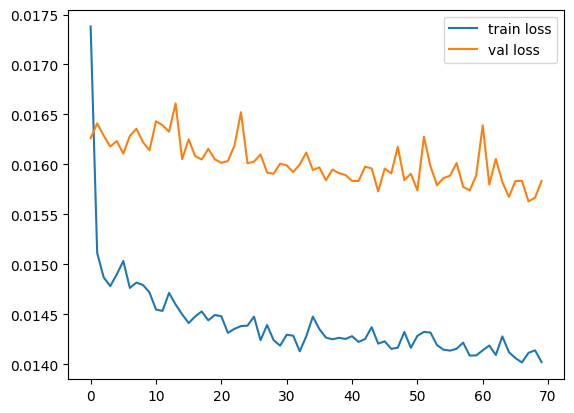

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [32]:
from sklearn.metrics import r2_score

# Predictions on test set
y_pred = model.predict(X_test)

# R² score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
R² Score: 0.31706785218333655
